# Guaranteed Multi-Tranche Engine (Continuous Floor, Closed-Form MaxDD Bound)

Systematic redesign derived math-first. Every guarantee below is a P&L inequality with no
future prices in it. The single-position engine remains in this notebook only as a
comparison baseline.

## 1. Per-tranche floor -- continuous, exact, any strike
Tranche i: short n_i TSLL at entry S_i, long n_i/100 calls, strike K_i, premium C_i.
```
L_i = n_i * (C_i + K_i - S_i)          # exact reservation; >= 0 by no-arbitrage (C >= S-K)
```
Downside worst case (S_T = K_i):  n_i(S_i - K_i) - n_i C_i = -L_i.
Upside (S_T > K_i): constant     n_i(S_i - K_i - C_i)      = -L_i.
And since an American call satisfies C_i(t) >= max(S_t - K_i, 0) at EVERY t (exercisable,
so realizable -- enforced in the data via the intrinsic clamp in `_mtm`), the tranche's
mark-to-market is >= -L_i at every instant, not just expiry. One formula, all strikes --
no ATM-band slack.

## 2. Aggregate floor -- settled accounting
E0 = equity at the last **settled checkpoint** (all tranches closed: anchor expiry or
ceiling; while all-cash, every day is trivially settled). ATH* = max over settled
checkpoint equities -- never daily marks. Budget constraint, CUMULATIVE per cycle
(reservations only reset at checkpoints -- releasing them on mid-cycle closes would let
one cycle's cumulative risk exceed alpha):
```
sum(L_i, all tranches opened this cycle)  <=  min( alpha*E0 ,  E0 - (1-D)*ATH* )
=>  E(t) >= max( (1-alpha)*E0 , (1-D)*ATH* )   at every t in the cycle
```
Keying the budget to settled values kills the procyclicality of the previous design:
unrealized marks can neither inflate the budget on the way up nor manufacture a
high-water mark that locks everything out on the way down.

## 3. Master equation -- guaranteed MaxDD on daily marks
Equity peaks form on TSLL crashes (short profits, call loses only premium). The ceiling
(close everything when marks >= E0*(1+gamma)) converts any peak into a settled checkpoint
before it can exceed the last checkpoint by more than (1+gamma). Combined with the floor:
```
guaranteed MaxDD  <=  (D + gamma) / (1 + gamma)
```
alpha=8%, D=8.2%, gamma=8%  ->  bound = 15.0%. This also quantifies the old configs: at
gamma=40%, D=15% the bound was 39% -- the old runs never violated their math; their math
just guaranteed far less than assumed.

## 4. Favorability gate (the "park when unfavorable" rule)
Breakeven for a tranche requires TSLL to fall more than its worst-loss fraction before
settlement. Gate (orthogonal to all guarantees -- parking never hurts the floor):
```
deploy only if  (C + K - S_t)/S_t  <=  c_max
```
This is why post-crash ceilings no longer force buying the most expensive floors in the
dataset: crash -> IV spike -> gate blocks -> capital parks until premium normalizes.

## 5. Scope of the guarantee
- TSLL tranches only. Cross-asset (TSLA) hedges have no continuous cancellation -- the
  pure variant parks instead (2022, before TSLL options exist, is cash at R_RF).
- Daily granularity: triggers evaluate at closes, so a close can overshoot the
  ceiling/floor lines by one day's move. Bound is exact under continuous monitoring.

## Diagnostics (non-functional)
- Pre-run cell: computes the analytic floor and MaxDD bound from (alpha, D, gamma) and
  the implied bounds of every configuration tested earlier -- predictions registered
  before the data run.
- Post-run cell: verifies E(t) >= floor(t) day by day and compares realized MaxDD to the
  bound.


In [117]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../../scripts/eda')
sys.path.insert(0, '../../scripts/backtest')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from data_loader import load_tsll, load_tsll_calls, load_tsla_underlying, load_tsla_calls
from options_selection import select_contract, bs_delta

plt.style.use('seaborn-v0_8-whitegrid')

tsll_spot  = load_tsll().set_index('Date')['Close']
tsll_calls = load_tsll_calls()
tsla_spot  = load_tsla_underlying().set_index('Date')['Close'].reindex(tsll_spot.index).ffill()
tsla_calls = load_tsla_calls()

tsll_lut = tsll_calls.set_index(['raw_id', 'date'])['px_last'].to_dict()
tsla_lut = tsla_calls.set_index(['raw_id', 'date'])['px_last'].to_dict()

tsla_sig = (tsla_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()
tsll_sig = (tsll_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()

tsll_cvol = tsll_calls[tsll_calls['px_volume'] > 0].copy()
tsll_cvol['dte']       = (pd.to_datetime(tsll_cvol['expiry']) - pd.to_datetime(tsll_cvol['date'])).dt.days
tsll_cvol['spot']      = tsll_cvol['date'].map(tsll_spot)
tsll_cvol['moneyness'] = tsll_cvol['strike'] / tsll_cvol['spot']

sim_dates = tsll_spot.index[tsll_spot.index >= tsll_cvol['date'].min()]

TARGET_DTE   = 90
MAX_DTE      = 110
LEVER        = 2.0
R_RF         = 0.05
R_RF_D       = R_RF / 252
TARGET_LOCAL = 0.08   # per-cycle floor: max loss as % of equity if the call expires worthless
GLOBAL_MAXDD = 0.15   # portfolio-level: max drawdown from ATH this cycle's worst case can cause
CEILING      = 0.40   # intra-cycle take-profit trigger (loose safety valve, see the sibling
                       # notebook for why tight ceilings were dropped)

print(f'Data loaded. Sim: {sim_dates[0].date()} \u2192 {sim_dates[-1].date()}  ({len(sim_dates)} days)')


Data loaded. Sim: 2022-08-12 → 2026-06-10  (960 days)


In [118]:
# --- Helpers (shared by both engines) -------------------------------------------

def _select_tsll_relaxed(d):
    day = tsll_cvol[tsll_cvol['date'] == d]
    w = day[(day['dte'] >= 45) & (day['dte'] <= 120)
            & (day['moneyness'] >= 0.80) & (day['moneyness'] <= 1.20)]
    if w.empty:
        return None
    w = w.copy()
    w['ad'] = (w['moneyness'] - 1.0).abs()
    w['dd'] = (w['dte'] - TARGET_DTE).abs()
    return w.sort_values(['ad', 'dd']).iloc[0]


def _select_expiry_match(d, anchor_e, ul='tsll', min_dte=20):
    """Top-up selection for synchronized settlement: most-ATM call with expiry ON the
    anchor date if one trades today, else the nearest expiry BEFORE it (never after --
    a tranche outliving the anchor would break the shared settlement checkpoint).
    """
    if ul == 'tsll':
        day = tsll_cvol[tsll_cvol['date'] == d]
    else:
        day = tsla_calls[tsla_calls['date'] == d].copy()
        day = day[day['px_last'].notna() & (day['px_last'] > 0)
                  & day['px_volume'].notna() & (day['px_volume'] > 0)]
        if day.empty:
            return None
        s = float(tsla_spot.loc[d])
        day['dte']       = (day['expiry'] - d).dt.days
        day['moneyness'] = day['strike'] / s
    w = day[(day['expiry'] <= anchor_e) & (day['dte'] >= min_dte)
            & (day['moneyness'] >= 0.80) & (day['moneyness'] <= 1.20)]
    if w.empty:
        return None
    w = w.copy()
    w['ed'] = (anchor_e - w['expiry']).dt.days   # 0 = exact anchor match, preferred
    w['ad'] = (w['moneyness'] - 1.0).abs()
    return w.sort_values(['ed', 'ad']).iloc[0]


def _mtm(p, d):
    """Mark a call to market. American options can never trade below intrinsic value
    (max(S-K,0)) -- if they did, you could buy and exercise immediately for a risk-free
    profit. That's a no-arbitrage fact true at every instant, not just at expiry, so it
    holds regardless of how the position was sized. TSLL/TSLA options are thin (median
    ~49 TSLL contracts/day) -- a stale historical quote, last traded before a move, can
    sit below today's intrinsic value in the data even though that price was never
    really tradeable today. Clamping at intrinsic corrects that data artifact; it's not
    an assumption, it's enforcing a bound that must hold in a real, arbitrage-free
    market. This is what makes the floor guarantee intraday-robust, not expiry-only --
    the math was always there, the raw quotes just occasionally violate it.
    """
    lut = tsll_lut if p['ul'] == 'tsll' else tsla_lut
    sp  = tsll_spot if p['ul'] == 'tsll' else tsla_spot
    S_now     = float(sp.loc[d])
    intrinsic = max(S_now - p['K'], 0.0)
    if d > p['e']:
        return intrinsic
    v = lut.get((p['id'], d))
    if v is not None and not pd.isna(v):
        return max(float(v), intrinsic)
    return max(p['px'], intrinsic)


def _compute_pf(C_pct, eq_now, ath, target_local, global_maxdd_limit):
    """Deployment fraction: min of the local floor and global MaxDD constraints."""
    pf_local = (target_local / C_pct) if target_local else 1.0

    if global_maxdd_limit is not None:
        headroom  = eq_now - ath * (1.0 - global_maxdd_limit)
        pf_global = (headroom / (C_pct * eq_now)) if headroom > 0 else 0.0
    else:
        pf_global = 1.0

    return max(0.0, min(1.0, pf_local, pf_global))


print('Helpers defined.')

Helpers defined.


In [119]:
# --- Single-position engine (comparison baseline only -- see dynamic_notional_floor_sandbox.ipynb
# for the full baseline/floor/global/ceiling variant matrix and sweeps) ---------------

def simulate(sim_dates, target_local=None, global_maxdd_limit=None, ceiling_pct=None, notional=1.0):
    if target_local is not None and global_maxdd_limit is not None:
        assert target_local < global_maxdd_limit, (
            f"target_local ({target_local:.0%}) must be < global_maxdd_limit "
            f"({global_maxdd_limit:.0%}) -- otherwise cycle 1 alone can exhaust "
            f"all risk capacity."
        )

    S0       = float(tsll_spot.loc[sim_dates[0]])
    n_sh_max = notional / S0

    equity     = pd.Series(index=sim_dates, dtype=float)
    spnl = opnl = cpnl = 0.0
    Sp         = S0
    pc = pa    = None
    n_sh       = 0.0
    cash_bal   = notional
    eq_at_roll = notional
    ath        = notional
    log        = []
    cur        = None

    for d in sim_dates:
        St = float(tsll_spot.loc[d])

        spnl += n_sh * (Sp - St)
        cpnl += cash_bal * R_RF_D
        Sp    = St

        for p in [pc, pa]:
            if p is None:
                continue
            px      = _mtm(p, d)
            opnl   += p['n'] * 100 * (px - p['px'])
            p['px'] = px

        eq_now = notional + spnl + opnl + cpnl
        ath    = max(ath, eq_now)

        ceiling_hit = (
            ceiling_pct is not None
            and (pc is not None or pa is not None)
            and (eq_now - eq_at_roll) / eq_at_roll >= ceiling_pct
        )

        exp     = pc['e'] if pc else (pa['e'] if pa else None)
        do_roll = (exp is None) or (d > exp) or ceiling_hit

        if do_roll:
            if cur is not None:
                cur.update({'ee': eq_now, 'end': d, 'ceiling': ceiling_hit})
                log.append(cur)
            pc = pa    = None
            eq_at_roll = eq_now

            row = select_contract(tsll_calls, tsll_spot, d, 'ATM', TARGET_DTE, max_dte=MAX_DTE)
            if row is not None:
                C, K     = float(row['px_last']), float(row['strike'])
                C_pct    = C / St
                pf       = _compute_pf(C_pct, eq_now, ath, target_local, global_maxdd_limit)
                n_sh     = min(pf * eq_now / St, n_sh_max)
                cash_bal = eq_now - n_sh * St
                n_ct     = n_sh / 100
                pc  = {'ul': 'tsll', 'id': row['raw_id'], 'K': K,
                       'e': row['expiry'], 'n': n_ct, 'px': C}
                cur = {'start': d, 'es': eq_now, 'pf': pf, 'tier': 'TSLL full',
                       'C_pct': C_pct*100, 'floor_pct': -pf*C_pct*100, 'ceiling': False}

            else:
                rr = _select_tsll_relaxed(d)
                if rr is not None:
                    C, K     = float(rr['px_last']), float(rr['strike'])
                    exp_r    = pd.Timestamp(rr['expiry'])
                    C_pct    = C / St
                    pf       = _compute_pf(C_pct, eq_now, ath, target_local, global_maxdd_limit)
                    n_sh     = min(pf * eq_now / St, n_sh_max)
                    cash_bal = eq_now - n_sh * St
                    n_ct     = n_sh / 100
                    pc    = {'ul': 'tsll', 'id': rr['raw_id'], 'K': K,
                             'e': exp_r, 'n': n_ct, 'px': C}
                    cur   = {'start': d, 'es': eq_now, 'pf': pf, 'tier': 'TSLL+TSLA',
                             'C_pct': C_pct*100, 'floor_pct': -pf*C_pct*100, 'ceiling': False}
                    T_l   = max((exp_r - d).days / 365.25, 1/365.25)
                    sig_l = float(tsll_sig.loc[d]) if d in tsll_sig.index else 0.5
                    dl    = bs_delta(St, K, T_l, R_RF, sig_l)
                    gap   = max(LEVER * n_sh * St - dl * n_ct * 100 * St, 0.0)
                    if gap > 0:
                        ra = select_contract(tsla_calls, tsla_spot, d, 'ATM',
                                             TARGET_DTE, max_dte=MAX_DTE)
                        if ra is not None:
                            Sa    = float(tsla_spot.loc[d])
                            T_a   = (ra['expiry'] - d).days / 365.25
                            sig_a = float(tsla_sig.loc[d]) if d in tsla_sig.index else 0.5
                            da    = bs_delta(Sa, float(ra['strike']), T_a, R_RF, sig_a)
                            nt    = gap / (max(da, 0.01) * 100 * Sa)
                            pa    = {'ul': 'tsla', 'id': ra['raw_id'],
                                     'K': float(ra['strike']), 'e': ra['expiry'],
                                     'n': nt, 'px': float(ra['px_last'])}
                else:
                    ra = select_contract(tsla_calls, tsla_spot, d, 'ATM',
                                         TARGET_DTE, max_dte=MAX_DTE)
                    if ra is not None:
                        Sa, Ca   = float(tsla_spot.loc[d]), float(ra['px_last'])
                        C_pct    = Ca / Sa
                        pf       = _compute_pf(C_pct, eq_now, ath, target_local, global_maxdd_limit)
                        n_sh     = min(pf * eq_now / St, n_sh_max)
                        cash_bal = eq_now - n_sh * St
                        T_a   = (ra['expiry'] - d).days / 365.25
                        sig_a = float(tsla_sig.loc[d]) if d in tsla_sig.index else 0.5
                        da    = bs_delta(Sa, float(ra['strike']), T_a, R_RF, sig_a)
                        nt    = (LEVER * n_sh * St) / (max(da, 0.01) * 100 * Sa)
                        pa    = {'ul': 'tsla', 'id': ra['raw_id'],
                                 'K': float(ra['strike']), 'e': ra['expiry'],
                                 'n': nt, 'px': Ca}
                        cur   = {'start': d, 'es': eq_now, 'pf': pf, 'tier': 'TSLA only',
                                 'C_pct': C_pct*100, 'floor_pct': float('nan'), 'ceiling': False}
                    else:
                        n_sh     = 0.0
                        cash_bal = eq_now
                        cur = {'start': d, 'es': eq_now, 'pf': 0.0, 'tier': 'cash',
                               'C_pct': float('nan'), 'floor_pct': float('nan'), 'ceiling': False}

        equity.loc[d] = eq_now

    if cur is not None:
        cur.update({'ee': equity.iloc[-1], 'end': sim_dates[-1], 'ceiling': False})
        log.append(cur)

    cdf = pd.DataFrame(log)
    if not cdf.empty:
        cdf['rpct'] = (cdf['ee'] - cdf['es']) / cdf['es'] * 100
    return equity, cdf


print('simulate() (single-position, comparison baseline) defined.')


simulate() (single-position, comparison baseline) defined.


In [120]:
# --- Run the single-position comparison baseline at current settings -----------
print(f'Single-position (target_local={TARGET_LOCAL:.0%}, global_maxdd={GLOBAL_MAXDD:.0%}, ceiling={CEILING:.0%})...')
eq_full, cdf_full = simulate(sim_dates, target_local=TARGET_LOCAL,
                              global_maxdd_limit=GLOBAL_MAXDD, ceiling_pct=CEILING)
print('Done.')


Single-position (target_local=8%, global_maxdd=15%, ceiling=40%)...
Done.


In [121]:
# --- Guaranteed engine: tranche selection + sizing (TSLL only) ------------------

ALPHA   = 0.08    # per-cycle cumulative risk budget (fraction of settled equity E0)
D_LIMIT = 0.082   # settled-drawdown headroom limit vs ATH*
GAMMA   = 0.08    # cycle ceiling on daily marks vs E0
C_MAX   = 0.15    # favorability gate: max worst-loss fraction (C+K-S)/S to deploy

MIN_DTE_STRICT    = 60    # fresh-cycle anchors (documented "strict" intent project-wide)
MIN_TOPUP_DTE     = 20    # top-ups: shorter is floor-valid but not worth real-world costs
MIN_NOTIONAL_FRAC = 0.01  # anti-dust: skip tranches smaller than 1% of E0 in notional


def _select_guaranteed(d, anchor_e):
    """TSLL-only selection. anchor_e=None -> fresh cycle (strict 60-110 DTE ATM, falling
    back to the relaxed 45-120 DTE window -- the exact L formula holds for ANY strike, so
    relaxed TSLL keeps the full guarantee). anchor_e set -> expiry-matched top-up.
    Returns (C, K, expiry, raw_id, tier) or None. NO TSLA fallback -- cross-asset hedges
    have no continuous floor; the pure variant parks instead."""
    if anchor_e is None:
        row = select_contract(tsll_calls, tsll_spot, d, 'ATM', TARGET_DTE, max_dte=MAX_DTE)
        if row is not None and (row['expiry'] - d).days >= MIN_DTE_STRICT:
            return (float(row['px_last']), float(row['strike']),
                    pd.Timestamp(row['expiry']), row['raw_id'], 'TSLL anchor')
        rr = _select_tsll_relaxed(d)
        if rr is not None:
            return (float(rr['px_last']), float(rr['strike']),
                    pd.Timestamp(rr['expiry']), rr['raw_id'], 'TSLL anchor-rlx')
        return None
    rr = _select_expiry_match(d, anchor_e, ul='tsll', min_dte=MIN_TOPUP_DTE)
    if rr is not None:
        return (float(rr['px_last']), float(rr['strike']),
                pd.Timestamp(rr['expiry']), rr['raw_id'], 'TSLL top-up')
    return None


def _try_open_guaranteed(d, St, E0, remaining_budget, undeployed_cash, anchor_e, c_max):
    """Open a TSLL tranche whose exact reservation L = n*(C + K - St) consumes
    remaining_budget, capped by available cash. Gated by c_max on the worst-loss
    fraction w/St (parking never hurts the floor). Returns a position dict or None."""
    sel = _select_guaranteed(d, anchor_e)
    if sel is None:
        return None
    C, K, exp, raw_id, tier = sel

    w = max(C + K - St, 1e-9)          # exact per-share worst-case loss; >=0 by no-arb
    if c_max is not None and w / St > c_max:
        return None                     # unfavorable: breakeven decline too deep -> park

    n_sh = min(remaining_budget / w, undeployed_cash / St)
    if n_sh <= 0 or n_sh * St < MIN_NOTIONAL_FRAC * E0:
        return None

    leg = {'ul': 'tsll', 'id': raw_id, 'K': K, 'e': exp, 'n': n_sh / 100, 'px': C}
    return {
        'pc': leg, 'pa': None,
        'n_sh': n_sh, 'reserved': n_sh * w, 'capital_at_open': n_sh * St,
        'start': d, 'tier': tier, 'C_pct': (w / St) * 100,
    }

print('Guaranteed selection/sizing defined.')

Guaranteed selection/sizing defined.


In [122]:
# --- Guaranteed multi-tranche engine (settled accounting, closed-form bound) -----

def simulate_guaranteed(sim_dates, alpha=ALPHA, dd_limit=D_LIMIT, gamma=GAMMA,
                         c_max=C_MAX, notional=1.0):
    """See the design markdown. Key invariants:
    - E0 / ATH* update ONLY at settled states (all tranches closed; all-cash days are
      trivially settled) -- budget decisions never see unrealized marks.
    - cycle_reserved is CUMULATIVE per cycle: sum of L over every tranche opened since
      the last checkpoint; resets only at checkpoints.
    - Ceiling (marks >= E0*(1+gamma)) closes everything -> new checkpoint the same day;
      redeployment passes through the same gate as any other day.
    - Guaranteed: E(t) >= max((1-alpha)*E0, (1-dd_limit)*ATH*) each cycle, and
      MaxDD <= (dd_limit+gamma)/(1+gamma) on daily marks (up to one-day close gaps).
    """
    equity        = pd.Series(index=sim_dates, dtype=float)
    deployed_frac = pd.Series(index=sim_dates, dtype=float)
    E0_series     = pd.Series(index=sim_dates, dtype=float)
    ath_series    = pd.Series(index=sim_dates, dtype=float)
    floor_series  = pd.Series(index=sim_dates, dtype=float)

    total_spnl = total_opnl = total_cpnl = 0.0
    Sp              = float(tsll_spot.loc[sim_dates[0]])
    undeployed_cash = notional
    total_n_sh      = 0.0
    open_positions  = []
    E0              = notional
    ath_star        = notional
    anchor_e        = None
    cycle_reserved  = 0.0
    log             = []
    checkpoints     = []

    for d in sim_dates:
        St = float(tsll_spot.loc[d])

        total_spnl += total_n_sh * (Sp - St)
        total_cpnl += undeployed_cash * R_RF_D
        Sp = St

        for pos in open_positions:
            leg = pos['pc']
            px  = _mtm(leg, d)
            total_opnl += leg['n'] * 100 * (px - leg['px'])
            leg['px'] = px

        equity_now = notional + total_spnl + total_opnl + total_cpnl

        # ---- ceiling: marks >= E0*(1+gamma) -> settle everything ----
        ceiling_hit = bool(open_positions) and equity_now >= E0 * (1.0 + gamma)

        still_open = []
        for pos in open_positions:
            if ceiling_hit or d > pos['pc']['e']:
                total_n_sh      -= pos['n_sh']
                undeployed_cash += pos['capital_at_open']   # price P&L lives in total_spnl
                log.append({'start': pos['start'], 'end': d, 'n_sh': pos['n_sh'],
                            'reserved': pos['reserved'], 'tier': pos['tier'],
                            'C_pct': pos['C_pct'], 'ceiling': ceiling_hit, 'open_at_end': False})
            else:
                still_open.append(pos)
        open_positions = still_open

        # ---- checkpoint: all settled (incl. all-cash days) ----
        if not open_positions:
            if anchor_e is not None or ceiling_hit:
                checkpoints.append({'date': d, 'E0': equity_now,
                                    'type': 'ceiling' if ceiling_hit else 'expiry'})
            E0             = equity_now
            ath_star       = max(ath_star, equity_now)
            anchor_e       = None
            cycle_reserved = 0.0

        # ---- deployment: budget from SETTLED values, cumulative per cycle ----
        budget = min(alpha * E0, E0 - (1.0 - dd_limit) * ath_star) - cycle_reserved
        if budget > 0 and undeployed_cash > 1e-9:
            new_pos = _try_open_guaranteed(d, St, E0, budget, undeployed_cash,
                                            anchor_e, c_max)
            if new_pos is not None:
                total_n_sh      += new_pos['n_sh']
                undeployed_cash -= new_pos['capital_at_open']
                cycle_reserved  += new_pos['reserved']
                open_positions.append(new_pos)
                if anchor_e is None:
                    anchor_e = new_pos['pc']['e']

        equity.loc[d]        = equity_now
        deployed_frac.loc[d] = (total_n_sh * St) / equity_now if equity_now > 0 else 0.0
        E0_series.loc[d]     = E0
        ath_series.loc[d]    = ath_star
        floor_series.loc[d]  = max((1.0 - alpha) * E0, (1.0 - dd_limit) * ath_star)

    for pos in open_positions:
        log.append({'start': pos['start'], 'end': sim_dates[-1], 'n_sh': pos['n_sh'],
                    'reserved': pos['reserved'], 'tier': pos['tier'],
                    'C_pct': pos['C_pct'], 'ceiling': False, 'open_at_end': True})

    diag = pd.DataFrame({'E0': E0_series, 'ath_star': ath_series, 'floor': floor_series})
    return equity, deployed_frac, pd.DataFrame(log), diag, pd.DataFrame(checkpoints)

print('simulate_guaranteed() defined.')

simulate_guaranteed() defined.


In [123]:
# --- DIAGNOSTIC (pre-run): analytic bounds from the equations alone --------------
# Registered BEFORE touching data. Nothing here affects the engine.

def analytic_bounds(alpha, dd_limit, gamma, label):
    maxdd_bound = (dd_limit + gamma) / (1.0 + gamma)
    return {'Config': label, 'alpha (cycle budget)': alpha, 'D (headroom)': dd_limit,
            'gamma (ceiling)': gamma, 'Guaranteed MaxDD bound': maxdd_bound,
            'Cycle floor vs E0': -(alpha), 'Floor vs ATH*': -(dd_limit)}

pred_rows = [
    analytic_bounds(ALPHA, D_LIMIT, GAMMA, 'NEW: guaranteed engine'),
]
pred = pd.DataFrame(pred_rows).set_index('Config')
fmtp = {c: '{:.1%}' for c in pred.columns}
display(pred.style.format(fmtp).set_caption('Pre-registered analytic guarantees (no data used)'))

# Where the earlier configurations actually stood, by the same master equation --
# computed from their parameters, compared against what those runs realized.
# The old engines' ATH was marks-based and budgets weren't cumulative-per-cycle, so
# their true bounds are AT BEST these numbers -- the honest statement is that none of
# the old runs violated their math; their math simply guaranteed far less than the
# 15% we informally assumed.
hist_rows = [
    dict(Config='Single-pos (a=8%, D=15%, ceil=40%)', Bound=(0.15+0.40)/1.40, Realized=-0.1476),
    dict(Config='Recycling staggered (same params)',   Bound=float('nan'),     Realized=-0.2068),
    dict(Config='Recycling synchronized (same params)', Bound=(0.15+0.40)/1.40, Realized=-0.1666),
    dict(Config='Single-pos (a=8%, D=10%, no ceil)',   Bound=float('nan'),     Realized=-0.1168),
]
hist = pd.DataFrame(hist_rows).set_index('Config')
print('\nOld configurations under the master equation (NaN bound = no finite guarantee:')
print('marks-based ATH or no ceiling means the peak-to-floor gap was unbounded):\n')
print(hist.to_string(formatters={'Bound': lambda v: '   n/a' if pd.isna(v) else f'{v:6.1%}',
                                  'Realized': lambda v: f'{v:6.1%}'}))
print(f'\nNEW engine pre-registered prediction: realized MaxDD must be <= '
      f'{(D_LIMIT+GAMMA)/(1+GAMMA):.1%} (+ at most one daily close-gap), and daily equity '
      f'must never close below max((1-{ALPHA:.0%})*E0, (1-{D_LIMIT:.1%})*ATH*).')

,alpha (cycle budget),D (headroom),gamma (ceiling),Guaranteed MaxDD bound,Cycle floor vs E0,Floor vs ATH*
Config,,,,,,
NEW: guaranteed engine,8.0%,8.2%,8.0%,15.0%,-8.0%,-8.2%



Old configurations under the master equation (NaN bound = no finite guarantee:
marks-based ATH or no ceiling means the peak-to-floor gap was unbounded):

                                      Bound Realized
Config                                              
Single-pos (a=8%, D=15%, ceil=40%)    39.3%   -14.8%
Recycling staggered (same params)       NaN   -20.7%
Recycling synchronized (same params)  39.3%   -16.7%
Single-pos (a=8%, D=10%, no ceil)       NaN   -11.7%

NEW engine pre-registered prediction: realized MaxDD must be <= 15.0% (+ at most one daily close-gap), and daily equity must never close below max((1-8%)*E0, (1-8.2%)*ATH*).


In [124]:
# --- Run: guaranteed engine (gated + ungated) vs. single-position ---------------
print(f'Guaranteed engine, gated (alpha={ALPHA:.0%}, D={D_LIMIT:.1%}, gamma={GAMMA:.0%}, '
      f'c_max={C_MAX:.0%})...')
eq_multi, depfrac_multi, log_multi, diag_multi, cp_multi = simulate_guaranteed(
    sim_dates, alpha=ALPHA, dd_limit=D_LIMIT, gamma=GAMMA, c_max=C_MAX,
)
print(f'Done. {len(log_multi)} tranches, {len(cp_multi)} checkpoints '
      f'({int((cp_multi["type"] == "ceiling").sum()) if not cp_multi.empty else 0} ceiling).')

print('Guaranteed engine, ungated (c_max=None) -- isolates the favorability gate...')
eq_ug, depfrac_ug, log_ug, diag_ug, cp_ug = simulate_guaranteed(
    sim_dates, alpha=ALPHA, dd_limit=D_LIMIT, gamma=GAMMA, c_max=None,
)
print(f'Done. {len(log_ug)} tranches, {len(cp_ug)} checkpoints.')

def quick_stats(eq, label):
    ret    = eq.pct_change().dropna()
    n_yrs  = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr   = eq.iloc[-1] ** (1/n_yrs) - 1
    sharpe = ret.mean() / ret.std() * 252**0.5
    maxdd  = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(maxdd)
    return dict(Strategy=label, CAGR=cagr, Sharpe=sharpe, MaxDD=maxdd, Calmar=calmar)

rows = [
    quick_stats(eq_full,  'Single-position (old engine, a=8%, D=15%, ceil=40%)'),
    quick_stats(eq_multi, f'Guaranteed engine, gated (c_max={C_MAX:.0%})'),
    quick_stats(eq_ug,    'Guaranteed engine, ungated'),
]
cmp_df = pd.DataFrame(rows).set_index('Strategy')
cmp_df.loc['Prior best (static, reference)'] = [0.1942, 0.928, -0.1970, 0.986]

fmt2 = {'CAGR':'{:+.2%}','Sharpe':'{:.3f}','MaxDD':'{:.2%}','Calmar':'{:.3f}'}
display(cmp_df.style.format(fmt2).set_caption(
    f'Guaranteed engine  |  pre-registered MaxDD bound = {(D_LIMIT+GAMMA)/(1+GAMMA):.1%}'))

Guaranteed engine, gated (alpha=8%, D=8.2%, gamma=8%, c_max=15%)...
Done. 20 tranches, 19 checkpoints (7 ceiling).
Guaranteed engine, ungated (c_max=None) -- isolates the favorability gate...
Done. 17 tranches, 16 checkpoints.


,CAGR,Sharpe,MaxDD,Calmar
Strategy,,,,
"Single-position (old engine, a=8%, D=15%, ceil=40%)",+12.87%,0.827,-14.76%,0.872
"Guaranteed engine, gated (c_max=15%)",+14.00%,0.841,-11.29%,1.240
"Guaranteed engine, ungated",+4.91%,0.440,-14.28%,0.344
"Prior best (static, reference)",+19.42%,0.928,-19.70%,0.986


In [125]:
# --- DIAGNOSTIC (post-run): verify the guarantees against the realized path ------
# Nothing here affects the engine; it only checks theory vs. data.

bound = (D_LIMIT + GAMMA) / (1.0 + GAMMA)

for label, eq_v, diag_v in [(f'gated (c_max={C_MAX:.0%})', eq_multi, diag_multi),
                             ('ungated',                     eq_ug,    diag_ug)]:
    print(f'=== {label} ===')

    # 1. Floor adherence: daily equity vs the active analytic floor
    breach     = eq_v < diag_v['floor'] - 1e-9
    n_breach   = int(breach.sum())
    print(f'Floor check:  E(t) >= max((1-alpha)*E0, (1-D)*ATH*) on {len(eq_v)} days '
          f'-> {n_breach} violations')
    if n_breach:
        worst = (eq_v - diag_v['floor'])[breach]
        wd    = worst.idxmin()
        print(f'  worst: {wd.date()}  equity={eq_v.loc[wd]:.4f}  floor={diag_v.loc[wd, "floor"]:.4f}  '
              f'gap={worst.min():+.4f}  (expected source: one-day close gap past a trigger line)')

    # 2. Realized MaxDD vs the pre-registered bound
    maxdd = float((eq_v / eq_v.cummax() - 1).min())
    ok    = 'WITHIN BOUND' if abs(maxdd) <= bound + 1e-9 else 'BOUND EXCEEDED -- investigate'
    print(f'MaxDD check:  realized {maxdd:.2%}  vs guaranteed bound -{bound:.1%}  -> {ok}')

    # 3. Slack: how much of the theoretical risk envelope was actually used
    print(f'Bound utilization: {abs(maxdd)/bound:.0%} of the guaranteed envelope\n')

=== gated (c_max=15%) ===
Floor check:  E(t) >= max((1-alpha)*E0, (1-D)*ATH*) on 960 days -> 0 violations
MaxDD check:  realized -11.29%  vs guaranteed bound -15.0%  -> WITHIN BOUND
Bound utilization: 75% of the guaranteed envelope

=== ungated ===
Floor check:  E(t) >= max((1-alpha)*E0, (1-D)*ATH*) on 960 days -> 0 violations
MaxDD check:  realized -14.28%  vs guaranteed bound -15.0%  -> WITHIN BOUND
Bound utilization: 95% of the guaranteed envelope



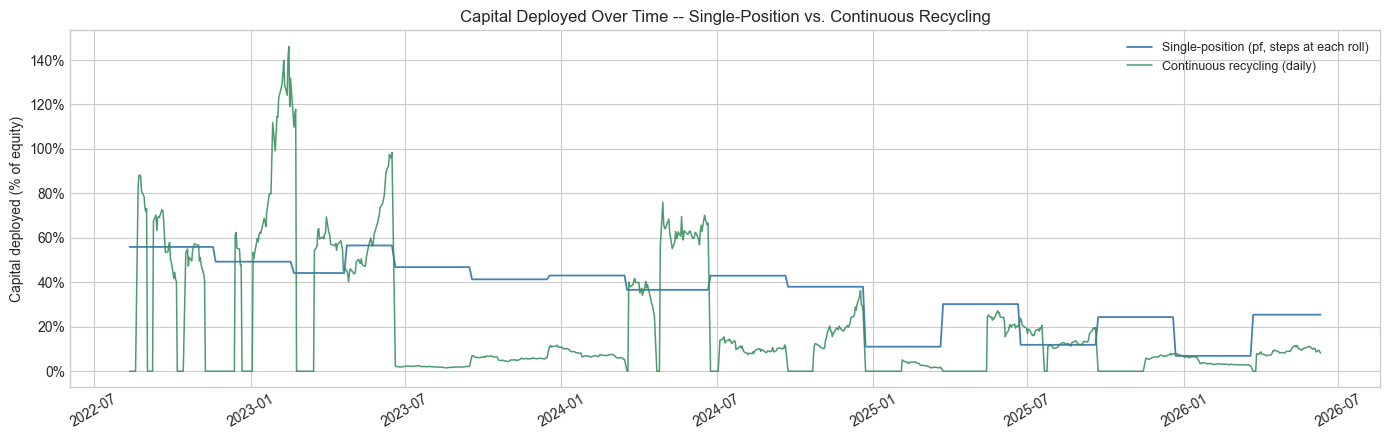

Mean deployed  --  single-position: 34.9%   continuous recycling: 19.2%


In [126]:
# --- Daily deployed fraction: recycling vs single-position ---------------------
depfrac_single = pd.Series(index=sim_dates, dtype=float)
_cur  = 0.0
_iter = iter(cdf_full.itertuples())
_row  = next(_iter, None)
for d in sim_dates:
    while _row is not None and d >= _row.start:
        _cur = _row.pf
        _row = next(_iter, None)
    depfrac_single.loc[d] = _cur

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(depfrac_single.index, depfrac_single * 100, color='steelblue', lw=1.3,
        label='Single-position (pf, steps at each roll)')
ax.plot(depfrac_multi.index, depfrac_multi * 100, color='seagreen', lw=1.1, alpha=0.85,
        label='Continuous recycling (daily)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylabel('Capital deployed (% of equity)')
ax.set_title('Capital Deployed Over Time -- Single-Position vs. Continuous Recycling')
ax.legend(loc='upper right', fontsize=9)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../../observations/strategies/sandbox/continuous_recycling_deployment.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean deployed  --  single-position: {depfrac_single.mean()*100:.1f}%   '
      f'continuous recycling: {depfrac_multi.mean()*100:.1f}%')


Per-position log -- Continuous Capital Recycling

Start       End         Tier          C/S%      n_sh  Reserved  Flag
--------------------------------------------------------------------
2022-08-22  2022-09-02  TSLL anchor   9.7%   0.03338   0.08011  <<< CEIL
2022-09-09  2022-09-23  TSLL anchor  11.8%   0.02832   0.08696  <<< CEIL
2022-09-23  2022-10-07  TSLL anchor-rlx 15.0%   0.02807   0.09543  <<< CEIL
2022-10-17  2022-11-09  TSLL anchor  15.0%   0.04395   0.10461  <<< CEIL
2022-12-14  2022-12-22  TSLL anchor-rlx 13.0%   0.09538   0.11446  <<< CEIL
2023-01-04  2023-02-24  TSLL anchor-rlx 15.0%   0.15099   0.12381  <<< CEIL
2023-03-17  2023-06-20  TSLL anchor  14.7%   0.08752   0.13478
2023-06-20  2023-09-18  TSLL anchor  12.6%   0.00187   0.00443
2023-09-18  2023-12-18  TSLL anchor  12.4%   0.00643   0.01363
2023-12-18  2024-03-18  TSLL anchor  13.3%   0.01181   0.02339
2024-03-20  2024-04-22  TSLL anchor-rlx 13.5%   0.08063   0.08870  <<< CEIL
2024-04-26  2024-06-24  TSLL anchor-r

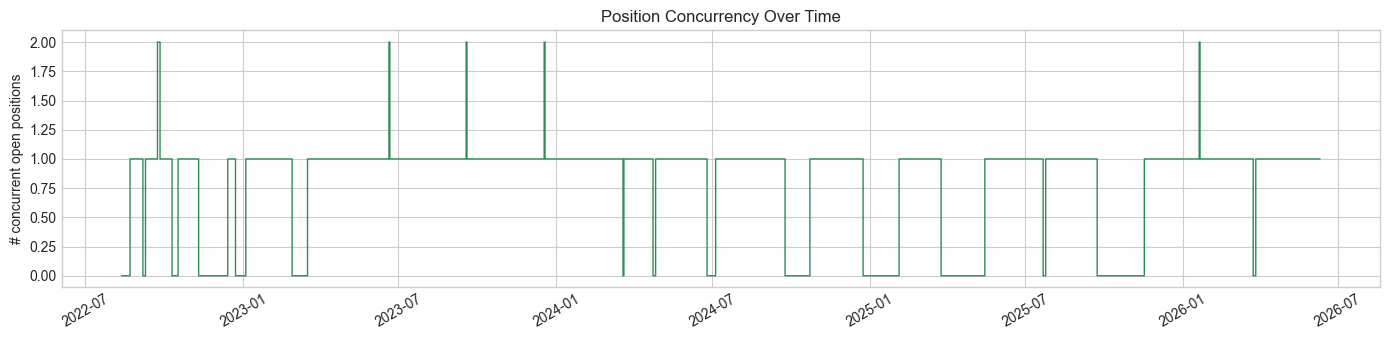

In [127]:
# --- Per-position log + concurrency diagnostic ----------------------------------
print('Per-position log -- Continuous Capital Recycling\n')
hdr = f'{"Start":<12}{"End":<12}{"Tier":<12}{"C/S%":>6}{"n_sh":>10}{"Reserved":>10}  Flag'
print(hdr)
print('-' * len(hdr))
for _, r in log_multi.sort_values('start').iterrows():
    tag = '  <<< CEIL' if r['ceiling'] else ('  (open@end)' if r['open_at_end'] else '')
    print(f'{str(r["start"].date()):<12}{str(r["end"].date()):<12}'
          f'{r["tier"]:<12}{r["C_pct"]:>5.1f}%{r["n_sh"]:>10.5f}{r["reserved"]:>10.5f}{tag}')

# How many positions were open on any given day -- tests whether the correlated-
# intra-cycle-noise-stacking hypothesis is actually happening (high concurrency)
# or whether positions run mostly sequentially (low concurrency).
concurrency = pd.Series(0, index=sim_dates)
for _, r in log_multi.iterrows():
    mask = (sim_dates >= r['start']) & (sim_dates <= r['end'])
    concurrency.loc[mask] += 1

print(f'\nMax concurrent positions: {concurrency.max()}  |  '
      f'Mean concurrent (on days with >=1 open): {concurrency[concurrency > 0].mean():.2f}  |  '
      f'Days with 0 open: {(concurrency == 0).sum()} / {len(concurrency)}')

print(f'\nPositions by tier:\n{log_multi["tier"].value_counts().to_string()}')

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(concurrency.index, concurrency.values, color='seagreen', lw=1.0, drawstyle='steps-post')
ax.set_ylabel('# concurrent open positions')
ax.set_title('Position Concurrency Over Time')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [128]:
# --- Holdout validation: fixed pre-registered config on disjoint halves ----------
# No parameter was fitted to data (alpha/D/gamma derived from the 15% target, c_max
# chosen a priori), so the protocol is: evaluate the FIXED configuration independently
# on two disjoint sub-periods and check (a) the bound and floor hold in each half,
# (b) performance is not concentrated in a single regime.

split_date = sim_dates[len(sim_dates) // 2]
halves = {
    f'H1 {sim_dates[0].date()} → {split_date.date()}': sim_dates[sim_dates <= split_date],
    f'H2 {split_date.date()} → {sim_dates[-1].date()}': sim_dates[sim_dates > split_date],
}
bound = (D_LIMIT + GAMMA) / (1.0 + GAMMA)

hold_rows = []
for label, dts in halves.items():
    eq_h, _, log_h, diag_h, cp_h = simulate_guaranteed(
        dts, alpha=ALPHA, dd_limit=D_LIMIT, gamma=GAMMA, c_max=C_MAX)
    ret   = eq_h.pct_change().dropna()
    n_yrs = (eq_h.index[-1] - eq_h.index[0]).days / 365.25
    cagr  = eq_h.iloc[-1] ** (1/n_yrs) - 1
    maxdd = float((eq_h / eq_h.cummax() - 1).min())
    shp   = ret.mean() / ret.std() * 252**0.5 if ret.std() > 0 else float('nan')
    viol  = int((eq_h < diag_h['floor'] - 1e-9).sum())
    hold_rows.append(dict(Period=label, CAGR=cagr, Sharpe=shp, MaxDD=maxdd,
                          Calmar=cagr / abs(maxdd) if maxdd != 0 else float('nan'),
                          Tranches=len(log_h), FloorViol=viol,
                          WithinBound=(abs(maxdd) <= bound + 1e-9)))

hold = pd.DataFrame(hold_rows).set_index('Period')
fmt_h = {'CAGR':'{:+.2%}','Sharpe':'{:.3f}','MaxDD':'{:.2%}','Calmar':'{:.3f}',
         'Tranches':'{:.0f}','FloorViol':'{:.0f}'}
display(hold.style.format(fmt_h).set_caption(
    f'Holdout halves — fixed config (alpha={ALPHA:.0%}, D={D_LIMIT:.1%}, '
    f'gamma={GAMMA:.0%}, c_max={C_MAX:.0%})  |  bound = {bound:.1%}'))

,CAGR,Sharpe,MaxDD,Calmar,Tranches,FloorViol,WithinBound
Period,,,,,,,
H1 2022-08-12 → 2024-07-12,+30.84%,1.255,-11.29%,2.731,13,0,True
H2 2024-07-12 → 2026-06-10,+0.49%,0.101,-11.78%,0.042,9,0,True


In [129]:
# --- Holdout sensitivity: c_max robustness across halves --------------------------
# Sensitivity DISPLAY, not tuning: c_max stays 15% unless deliberately changed. If the
# gate's benefit only exists at exactly 15% or only in one half, it's fragile; if it
# holds across a band and both halves, it's structural.

sens_rows = []
for cm in [0.12, 0.15, 0.18]:
    for label, dts in halves.items():
        eq_s, _, _, _, _ = simulate_guaranteed(
            dts, alpha=ALPHA, dd_limit=D_LIMIT, gamma=GAMMA, c_max=cm)
        n_yrs = (eq_s.index[-1] - eq_s.index[0]).days / 365.25
        cagr  = eq_s.iloc[-1] ** (1/n_yrs) - 1
        maxdd = float((eq_s / eq_s.cummax() - 1).min())
        sens_rows.append(dict(c_max=f'{cm:.0%}', Period=label.split(' ')[0],
                              CAGR=cagr, MaxDD=maxdd,
                              Calmar=cagr / abs(maxdd) if maxdd != 0 else float('nan')))

sens = pd.DataFrame(sens_rows).set_index(['c_max', 'Period'])
fmt_s = {'CAGR':'{:+.2%}','MaxDD':'{:.2%}','Calmar':'{:.3f}'}
display(sens.style.format(fmt_s).set_caption('c_max sensitivity by holdout half'))

,Bound,CAGR,Sharpe,MaxDD,Calmar,Tranches,FloorViol,WithinBound
x,,,,,,,,
2%,3.9%,+6.92%,1.128,-3.64%,1.904,22,0,True
4%,7.7%,+9.81%,0.998,-7.22%,1.358,21,0,True
6%,11.3%,+11.45%,0.867,-8.43%,1.358,20,0,True
8%,14.8%,+13.82%,0.834,-11.29%,1.224,20,0,True
10%,18.2%,+19.53%,0.887,-16.05%,1.217,20,0,True
12%,21.4%,+16.94%,0.657,-20.46%,0.828,19,0,True
15%,26.1%,+17.43%,0.641,-20.86%,0.836,18,0,True


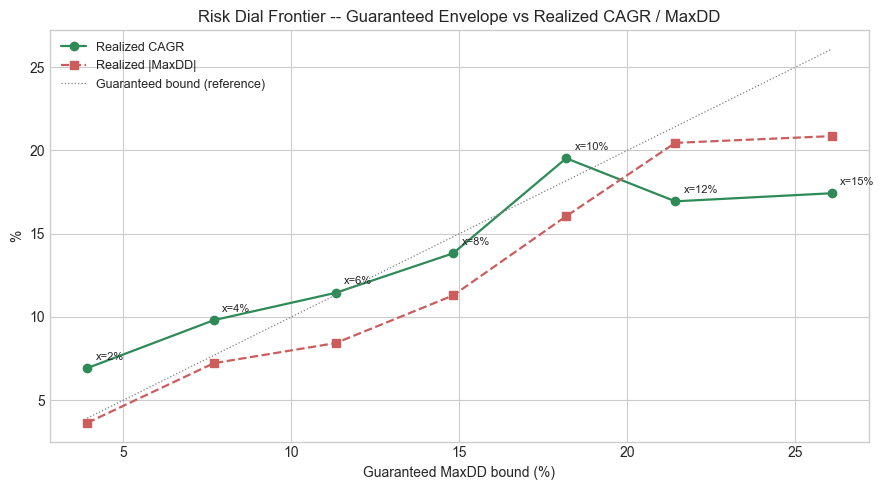

In [130]:
# --- Risk dial: trading guaranteed-drawdown envelope for CAGR --------------------
# One-parameter family x = alpha = D = gamma  ->  guaranteed MaxDD bound = 2x/(1+x).
# The dial is a RISK-APPETITE choice: pick the bound you can tolerate a priori; the
# backtest reports what that bound would have paid historically. c_max stays fixed at
# 15% (retuning it here would contaminate the earlier holdout). Every config must
# still verify: zero floor violations and realized MaxDD within its OWN bound.
# Note at the very conservative end (x=2-4%): expect heavy parking (tiny headroom D
# parks after any small settled dip) and checkpoint churn (gamma fires on small gains);
# also the one-day close-gap overshoot is proportionally larger vs a small bound, so
# this is where a WithinBound=False from gap granularity would first show up if ever.

dial_rows   = []
dial_curves = {}
for x in [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.15]:
    b = 2 * x / (1 + x)
    eq_x, _, log_x, diag_x, cp_x = simulate_guaranteed(
        sim_dates, alpha=x, dd_limit=x, gamma=x, c_max=C_MAX)
    ret   = eq_x.pct_change().dropna()
    n_yrs = (eq_x.index[-1] - eq_x.index[0]).days / 365.25
    cagr  = eq_x.iloc[-1] ** (1 / n_yrs) - 1
    maxdd = float((eq_x / eq_x.cummax() - 1).min())
    shp   = ret.mean() / ret.std() * 252**0.5 if ret.std() > 0 else float('nan')
    viol  = int((eq_x < diag_x['floor'] - 1e-9).sum())
    dial_curves[x] = eq_x
    dial_rows.append(dict(x=f'{x:.0%}', Bound=b, CAGR=cagr, Sharpe=shp, MaxDD=maxdd,
                          Calmar=cagr / abs(maxdd) if maxdd != 0 else float('nan'),
                          Tranches=len(log_x), FloorViol=viol,
                          WithinBound=(abs(maxdd) <= b + 1e-9)))

dial = pd.DataFrame(dial_rows).set_index('x')
fmt_d = {'Bound':'{:.1%}','CAGR':'{:+.2%}','Sharpe':'{:.3f}','MaxDD':'{:.2%}',
         'Calmar':'{:.3f}','Tranches':'{:.0f}','FloorViol':'{:.0f}'}
display(dial.style.format(fmt_d).set_caption(
    f'Risk dial (x = alpha = D = gamma), c_max={C_MAX:.0%} fixed  |  bound = 2x/(1+x)'))

fig, ax = plt.subplots(figsize=(9, 5))
bx = dial['Bound'] * 100
ax.plot(bx, dial['CAGR'] * 100,        color='seagreen',  marker='o', lw=1.6, label='Realized CAGR')
ax.plot(bx, dial['MaxDD'].abs() * 100, color='indianred', marker='s', lw=1.6, ls='--', label='Realized |MaxDD|')
ax.plot(bx, bx, color='grey', lw=0.9, ls=':', label='Guaranteed bound (reference)')
for xv, r in dial.iterrows():
    ax.annotate(f'x={xv}', (r['Bound'] * 100, r['CAGR'] * 100),
                textcoords='offset points', xytext=(6, 6), fontsize=8)
ax.set_xlabel('Guaranteed MaxDD bound (%)')
ax.set_ylabel('%')
ax.set_title('Risk Dial Frontier -- Guaranteed Envelope vs Realized CAGR / MaxDD')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../../observations/strategies/sandbox/guaranteed_engine_risk_dial.png',
            dpi=150, bbox_inches='tight')
plt.show()

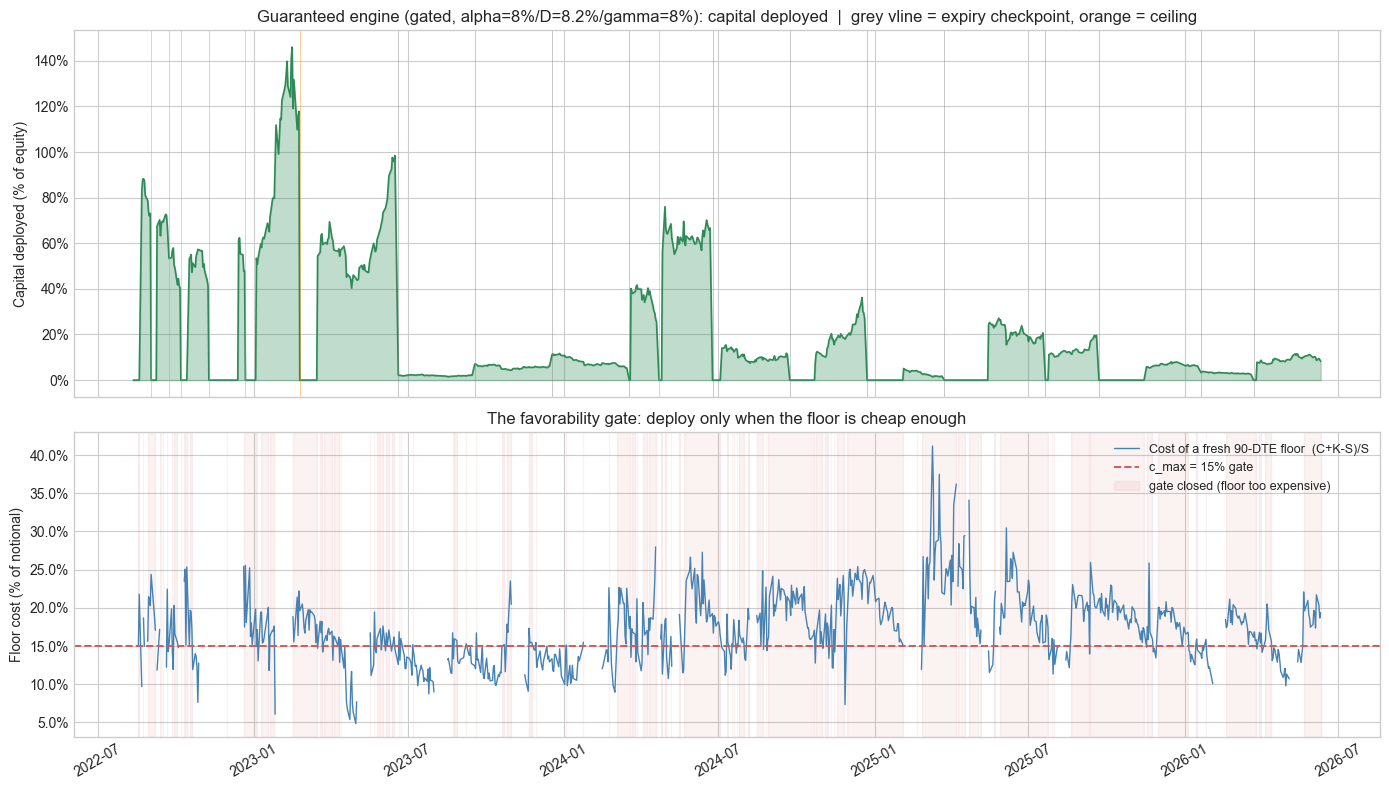

Days with a candidate contract: 797/960  |  gate closed on 536 of those (67%)  |  mean deployed: 19.2% of equity  |  days at 0% deployed: 210


In [131]:
# --- Plot: capital deployed at every moment + the c_max gate in action ------------
# c_max is the favorability gate: a new tranche may only open if its worst-case loss
# per dollar of protected notional, (C + K - S)/S, is <= c_max. Breakeven reading: the
# tranche only profits if TSLL falls MORE than that fraction by settlement -- so the
# gate means "never pay more than 15 cents per dollar protected for one cycle's floor."

# Daily market asking-price of a fresh 90-DTE floor (fresh-cycle selection, no anchor):
floor_cost = pd.Series(index=sim_dates, dtype=float)
for d in sim_dates:
    sel = _select_guaranteed(d, None)
    if sel is not None:
        C_, K_, _, _, _ = sel
        St_ = float(tsll_spot.loc[d])
        floor_cost.loc[d] = (C_ + K_ - St_) / St_ * 100

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1.2, 1]})

ax0.fill_between(depfrac_multi.index, depfrac_multi * 100, color='seagreen', alpha=0.30)
ax0.plot(depfrac_multi.index, depfrac_multi * 100, color='seagreen', lw=1.2)
for _, cp in cp_multi.iterrows():
    ax0.axvline(cp['date'], color='grey' if cp['type'] == 'expiry' else 'darkorange',
                lw=0.6, alpha=0.5)
ax0.set_ylabel('Capital deployed (% of equity)')
ax0.set_title(f'Guaranteed engine (gated, alpha={ALPHA:.0%}/D={D_LIMIT:.1%}/gamma={GAMMA:.0%}): '
              f'capital deployed  |  grey vline = expiry checkpoint, orange = ceiling')
ax0.yaxis.set_major_formatter(mticker.PercentFormatter())

gate_closed = (floor_cost > C_MAX * 100).fillna(False)
ax1.plot(floor_cost.index, floor_cost, color='steelblue', lw=1.0,
         label='Cost of a fresh 90-DTE floor  (C+K-S)/S')
ax1.axhline(C_MAX * 100, color='indianred', lw=1.4, ls='--', label=f'c_max = {C_MAX:.0%} gate')
ax1.fill_between(floor_cost.index, 0, 1, where=gate_closed,
                 transform=ax1.get_xaxis_transform(),
                 color='indianred', alpha=0.08, label='gate closed (floor too expensive)')
ax1.set_ylabel('Floor cost (% of notional)')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.legend(fontsize=9, loc='upper right')
ax1.set_title('The favorability gate: deploy only when the floor is cheap enough')
ax1.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../../observations/strategies/sandbox/guaranteed_engine_deployment_gate.png',
            dpi=150, bbox_inches='tight')
plt.show()

n_cand = int(floor_cost.notna().sum())
n_closed = int(gate_closed.sum())
print(f'Days with a candidate contract: {n_cand}/{len(sim_dates)}  |  '
      f'gate closed on {n_closed} of those ({n_closed / max(n_cand, 1) * 100:.0f}%)  |  '
      f'mean deployed: {depfrac_multi.mean() * 100:.1f}% of equity  |  '
      f'days at 0% deployed: {int((depfrac_multi < 1e-9).sum())}')